## Access Animal Satellite Relay Tagging Dive Realtime QC (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_dive_satellite_relay_tagging_realtime_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b2548767-514f-4a31-b65e-36bb894382d5).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_dive_satellite_relay_tagging_realtime_qc.ipynb).


In [1]:
dataset_name = "animal_dive_satellite_relay_tagging_realtime_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv


✅ Virtual environment already exists, skipping creation.


Resolved 201 packages in 68ms
Checked 201 packages in 1ms


✅ Local version 0.3.21 is up to date (remote: 0.3.18)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4624: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 11.3 ms, sys: 1.13 ms, total: 12.5 ms
Wall time: 10.9 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 546 µs, sys: 835 µs, total: 1.38 ms
Wall time: 1.37 ms


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


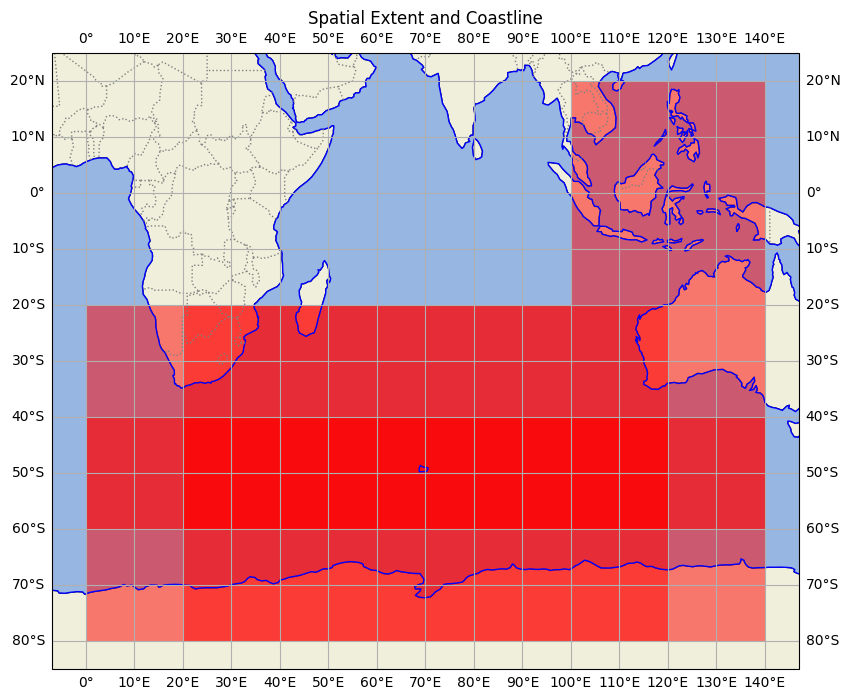

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 190 ms, sys: 55.5 ms, total: 245 ms
Wall time: 642 ms


(Timestamp('2025-12-19 20:29:52'), Timestamp('2026-05-31 04:09:28'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-06-02 19:10:18,626 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_dive_satellite_relay_tagging_realtime_qc.parquet


{'ref': {'type': 'string'},
 'ptt': {'type': 'int32'},
 'cnt': {'type': 'int32'},
 'de_date': {'type': 'timestamp[ns]'},
 'surf_dur': {'type': 'int32'},
 'dive_dur': {'type': 'int32'},
 'max_dep': {'type': 'double'},
 'd1': {'type': 'double'},
 'd2': {'type': 'double'},
 'd3': {'type': 'double'},
 'd4': {'type': 'double'},
 'v1': {'type': 'double'},
 'v2': {'type': 'double'},
 'v3': {'type': 'double'},
 'v4': {'type': 'double'},
 'v5': {'type': 'double'},
 'travel_r': {'type': 'double'},
 'homedist': {'type': 'double'},
 'bottom': {'type': 'double'},
 't1': {'type': 'double'},
 't2': {'type': 'double'},
 't3': {'type': 'double'},
 't4': {'type': 'double'},
 'd_speed': {'type': 'double'},
 'n_depths': {'type': 'int32'},
 'n_speeds': {'type': 'int32'},
 'depth_str': {'type': 'double'},
 'speed_str': {'type': 'double'},
 'propn_str': {'type': 'double'},
 'percent_area': {'type': 'double'},
 'residual': {'type': 'int32'},
 'grp_number': {'type': 'int32'},
 'd5': {'type': 'double'},
 't5': 

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
# NRT dataset, so we re just showing how to do a time filtering here taking the whole data
df = aodn_dataset.get_data(date_start=aodn_dataset.get_temporal_extent()[0].strftime('%Y-%m-%d'), 
                           date_end=aodn_dataset.get_temporal_extent()[1].strftime('%Y-%m-%d'),
                           )

df.info()

2026-06-02 19:10:19,985 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_dive_satellite_relay_tagging_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225484 entries, 0 to 225483
Columns: 114 entries, ref to polygon
dtypes: datetime64[ns](1), float64(99), int32(8), object(6)
memory usage: 189.2+ MB
CPU times: user 800 ms, sys: 430 ms, total: 1.23 s
Wall time: 1.42 s


In [11]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

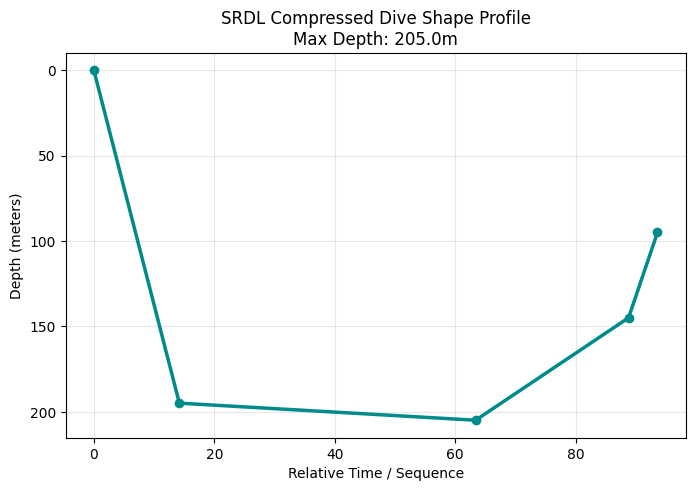

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Select a single deep dive from a specific seal
single_dive = df[df["max_dep"] > 200].iloc[0]

# Extract the paired time and depth inflection points (adjust range based on populated columns, e.g., 1-5 or 1-25)
times = [single_dive[f"t{i}"] for i in range(1, 6) if pd.notna(single_dive[f"t{i}"])]
depths = [single_dive[f"d{i}"] for i in range(1, 6) if pd.notna(single_dive[f"d{i}"])]

# Prepend the start of the dive (0 time, 0 depth)
times = [0] + times
depths = [0] + depths

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(times, depths, "o-", color="darkcyan", linewidth=2.5, label="Reconstructed Dive")

ax.set_ylabel("Depth (meters)")
ax.set_xlabel("Relative Time / Sequence")
ax.set_title(f"SRDL Compressed Dive Shape Profile\nMax Depth: {single_dive['max_dep']}m")
ax.invert_yaxis()  # Surface is at the top
ax.grid(True, alpha=0.3)
plt.show()

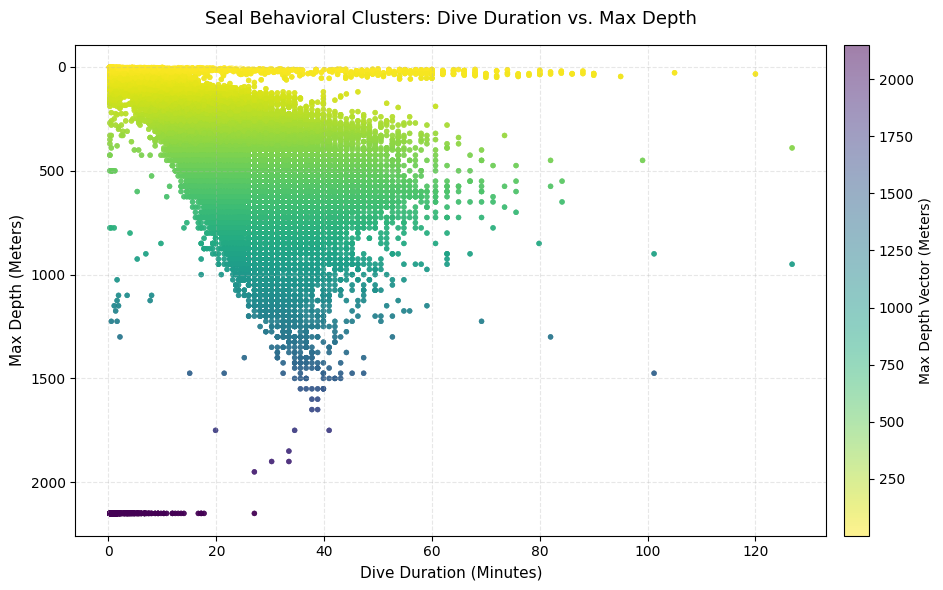

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Clean up any bad rows or missing values in our target columns first
plot_df = df.dropna(subset=["dive_dur", "max_dep"]).copy()

# Filter out rows where the dive duration or depth is 0 to remove corrupt pings
plot_df = plot_df[(plot_df["dive_dur"] > 0) & (plot_df["max_dep"] > 0)]

fig, ax = plt.subplots(figsize=(10, 6))

# Mapping color to max depth directly since it's verified in your schema
sc = ax.scatter(
    plot_df["dive_dur"] / 60,  # Convert seconds to minutes for readability
    plot_df["max_dep"],
    c=plot_df["max_dep"],      # Color points by how deep they went
    cmap="viridis_r",          # Good color gradient (reversed so deeper looks darker)
    alpha=0.5,
    s=15,
    edgecolors="none"
)

# Invert y-axis so the surface (0m) is at the top of the plot
ax.invert_yaxis()

ax.set_title("Seal Behavioral Clusters: Dive Duration vs. Max Depth", fontsize=13, pad=15)
ax.set_xlabel("Dive Duration (Minutes)", fontsize=11)
ax.set_ylabel("Max Depth (Meters)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.3)

cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Max Depth Vector (Meters)")

plt.tight_layout()
plt.show()